# Collective Posterior Samplers

This notebook demonstrates the main sampling options implemented for the collective posterior.

It defaults to `GLU`, but the setup cell is written so you can switch to another simulator and reuse the same workflow.

Sampling methods covered here:
- Rejection sampling
- MCMC from top candidates
- SIR with jitter
- Legacy adaptive tempered SIR with refinement
- Corrected adaptive SIR using an explicit adaptive proposal and final importance correction


## Setup

In [1]:
from pathlib import Path
import math
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from collective_posterior import CollectivePosterior
from evo_sim import EVO_SIM_wrapper, evo_sim
from inference_utils import get_prior
from simulators import GLU, GLU_wrapper, SLCP, SLCP_wrapper, WF, WF_wrapper

torch.set_grad_enabled(False)
torch.manual_seed(17)
sns.set_theme(style="whitegrid")

repo_root = Path.cwd()
assert (repo_root / "collective_posterior.py").exists(), "Run this notebook from Posterior/collective_posterior"

SIM_NAME = "EVO_SIM"  # Change to one of: GLU, SLCP, WF, EVO_SIM
NUM_REPS = 10
N_SAMPLES = 250
N_EVAL = 2_000
PLOT_DIMS = 6

DEFAULT_POSTERIORS = {
    "GLU": repo_root / "GLU" / "posteriors" / "posterior_GLU_100000_20.pkl",
    "SLCP": repo_root / "SLCP" / "posteriors" / "posterior_SLCP_100000_20.pkl",
    "WF": repo_root / "WF" / "posteriors" / "posterior_WF_30000_20.pkl",
    "EVO_SIM": repo_root / "EVO_SIM" / "posterior_EVO_SIM_30000_20.pkl",
}

SIMULATORS = {
    "GLU": GLU,
    "SLCP": SLCP,
    "WF": WF,
    "EVO_SIM": evo_sim,
}

WRAPPERS = {
    "GLU": GLU_wrapper,
    "SLCP": SLCP_wrapper,
    "WF": WF_wrapper,
    "EVO_SIM": EVO_SIM_wrapper,
}

EPSILONS = {
    "GLU": -10000,
    "SLCP": -10,
    "WF": -10,
    "EVO_SIM": -10,
}

posterior_path = DEFAULT_POSTERIORS[SIM_NAME]
assert posterior_path.exists(), f"Missing posterior file: {posterior_path}"

prior = get_prior(SIM_NAME)
simulator = SIMULATORS[SIM_NAME]
wrapper = WRAPPERS[SIM_NAME]
epsilon = EPSILONS[SIM_NAME]

with open(posterior_path, "rb") as handle:
    amortized_posterior = pickle.load(handle)

theta_true = prior.sample()
Xs = wrapper(reps=NUM_REPS, parameters=theta_true)

def build_cp():
    return CollectivePosterior(
        prior=prior,
        Xs=Xs,
        amortized_posterior=amortized_posterior,
        epsilon=epsilon,
        n_eval=N_EVAL,
    )

def get_prior_bounds(prior):
    if hasattr(prior, "base_dist") and hasattr(prior.base_dist, "low"):
        return prior.base_dist.low.detach().cpu(), prior.base_dist.high.detach().cpu()
    if hasattr(prior, "low") and hasattr(prior, "high"):
        return prior.low.detach().cpu(), prior.high.detach().cpu()
    try:
        return prior.support.base_constraint.lower_bound.detach().cpu(), prior.support.base_constraint.upper_bound.detach().cpu()
    except Exception:
        return None, None

def summarize_samples(samples, label, theta=None, max_dims=PLOT_DIMS):
    samples = torch.as_tensor(samples).detach().cpu()
    theta = None if theta is None else torch.as_tensor(theta).detach().cpu()
    dims = min(samples.shape[1], max_dims)
    prior_low, prior_high = get_prior_bounds(prior)
    colnames = [f"theta_{i}" for i in range(dims)]
    df = pd.DataFrame(samples[:, :dims].numpy(), columns=colnames)
    display(df.describe().T[["mean", "std", "min", "max"]])

    fig, axes = plt.subplots(1, dims, figsize=(4 * dims, 3.5))
    if dims == 1:
        axes = [axes]
    for i in range(dims):
        sns.histplot(df[colnames[i]], ax=axes[i], kde=True, color="tomato")
        if theta is not None:
            axes[i].axvline(float(theta[i]), color="black", linestyle="--", linewidth=2)
        if prior_low is not None and prior_high is not None:
            axes[i].set_xlim(float(prior_low[i]), float(prior_high[i]))
        axes[i].set_title(f"{label}: dim {i}")
    plt.tight_layout()
    plt.show()

print("Simulator:", SIM_NAME)
print("Posterior:", posterior_path.relative_to(repo_root))
print("theta dimension:", theta_true.shape[0])
print("replicate shape:", tuple(Xs.shape))
print("epsilon:", epsilon)

Simulator: EVO_SIM
Posterior: EVO_SIM/posterior_EVO_SIM_30000_20.pkl
theta dimension: 6
replicate shape: (10, 30)
epsilon: -10


True theta (first dimensions):


,true_theta
theta_0,-2.131517
theta_1,-1.929781
theta_2,-1.339583
theta_3,-7.504546
theta_4,-7.882716
theta_5,-5.802416


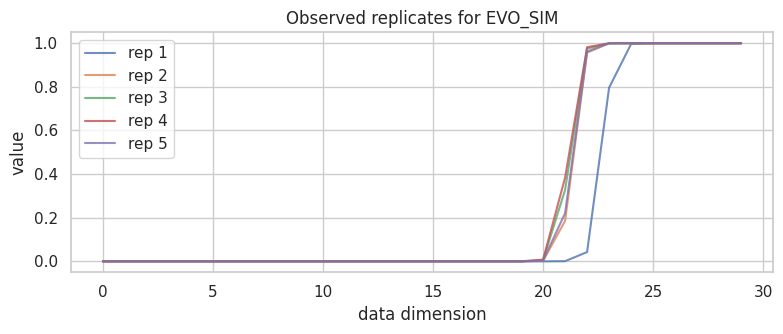

In [2]:
print("True theta (first dimensions):")
display(pd.DataFrame({"true_theta": theta_true.detach().cpu().numpy()[:min(len(theta_true), PLOT_DIMS)]}, index=[f"theta_{i}" for i in range(min(len(theta_true), PLOT_DIMS))]))

fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(min(NUM_REPS, 5)):
    ax.plot(Xs[i].detach().cpu().numpy(), alpha=0.8, label=f"rep {i+1}")
ax.set_title(f"Observed replicates for {SIM_NAME}")
ax.set_xlabel("data dimension")
ax.set_ylabel("value")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Rejection Sampling

This uses prior samples and accepts them according to the collective posterior score. It is simple and exact up to the usual rejection-sampling efficiency issues, but it can become slow in higher dimensions or for sharply concentrated posteriors.

In this implementation, `log_C` is estimated first because the collective posterior `log_prob` requires it.

Estimated log_C: 54.097267150878906


Rejection Sampling: 252it [00:16, 15.27it/s]                         

Rejection sample shape: (250, 6)


,mean,std,min,max
theta_0,-2.432151,0.244834,-2.911760,-1.639363
theta_1,-2.218209,0.441111,-2.998569,-1.119398
theta_2,-1.347859,0.023995,-1.652638,-1.315143
theta_3,-6.651730,0.508523,-7.868601,-5.477875
theta_4,-7.050091,0.536909,-7.988021,-4.000000
theta_5,-5.837705,0.252666,-6.425864,-4.449628


/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

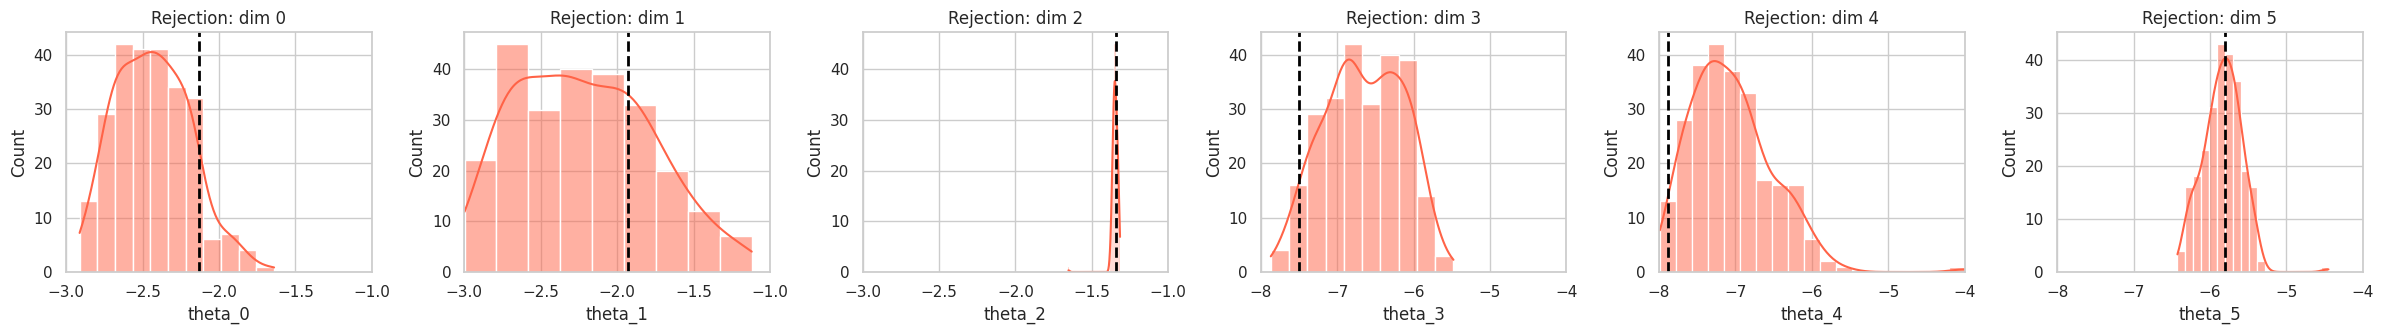

In [3]:
cp_rejection = build_cp()
log_C_rejection = cp_rejection.get_log_C(n_reps=1, S=0.05)
print("Estimated log_C:", float(log_C_rejection))

samples_rejection = cp_rejection.sample(
    n_samples=N_SAMPLES,
    method="rejection",
    jump=10_000,
    m=1.5,
    num_workers=10,
)

print("Rejection sample shape:", tuple(samples_rejection.shape))
summarize_samples(samples_rejection, "Rejection", theta_true)

## MCMC From Top Candidates

This path first uses `get_log_C()` to generate and rank a pool of promising prior samples, then starts independent Metropolis-Hastings chains from the top candidates. It is often a good compromise when pure rejection sampling becomes inefficient.

The important parameters here are:
- `take_sn`: how many top candidates to seed chains from
- `step_size`: proposal scale for the random walk

Estimated log_C: 44.92817306518555
Stored candidate pool: 100
take_sn: 20


MCMC from top 20 candidates: 100%|██████████| 1000/1000 [00:09<00:00, 98.01it/s]


MCMC sample shape: (1000, 6)


,mean,std,min,max
theta_0,-2.382175,0.457693,-3.061739,-1.458770
theta_1,-2.005855,0.637289,-3.009370,-0.978639
theta_2,-1.346225,0.056811,-1.489412,-1.183488
theta_3,-6.688040,0.811519,-8.003201,-5.327556
theta_4,-6.936290,0.641172,-7.803777,-5.763020
theta_5,-6.074749,0.663078,-7.767394,-5.086981


/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

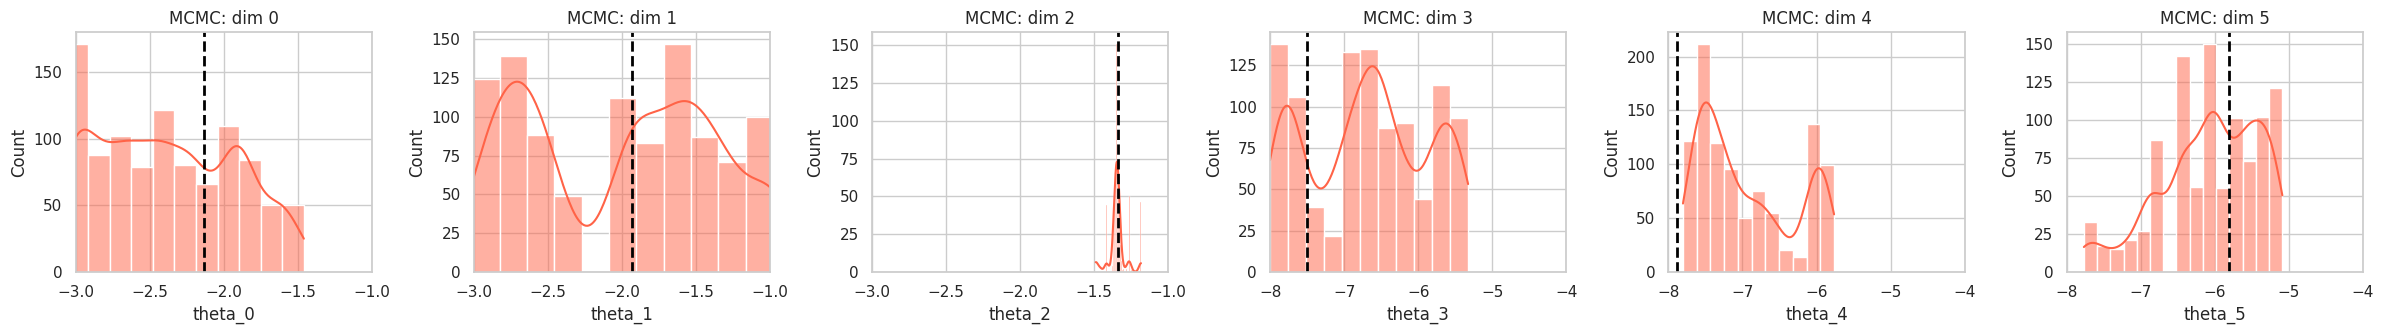

In [4]:
cp_mcmc = build_cp()
log_C_mcmc = cp_mcmc.get_log_C(n_reps=1, S=0.05)
take_sn = min(20, len(cp_mcmc.samples))
print("Estimated log_C:", float(log_C_mcmc))
print("Stored candidate pool:", len(cp_mcmc.samples))
print("take_sn:", take_sn)

samples_mcmc = cp_mcmc.sample(
    n_samples=1000,
    method="mcmc",
    take_sn=take_sn,
    step_size=0.05,
)

print("MCMC sample shape:", tuple(samples_mcmc.shape))
summarize_samples(samples_mcmc, "MCMC", theta_true)

## SIR With Jitter

This is a gradient-free importance-resampling method. It draws a pool from the prior, scores the pool under the robust collective posterior, resamples high-weight points, and then adds Gaussian jitter to smooth the sample set.

This is often the easiest method to use in practice because it does not require `log_C` and tends to work robustly with reasonable hyperparameters.

Evaluating 100000 samples: 100%|██████████| 10/10 [00:01<00:00,  6.66it/s]

Sampled 250 points with jitter and reflection. ESS = 15.972159385681152
SIR+jitter sample shape: (250, 6)


,mean,std,min,max
theta_0,-2.447275,0.159996,-2.946775,-2.070337
theta_1,-2.242773,0.469977,-2.998353,-1.009957
theta_2,-1.350751,0.013662,-1.392097,-1.315603
theta_3,-6.588616,0.409195,-7.835934,-5.487120
theta_4,-7.288330,0.449669,-7.994391,-5.615005
theta_5,-5.826522,0.126708,-6.210140,-5.499308


/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

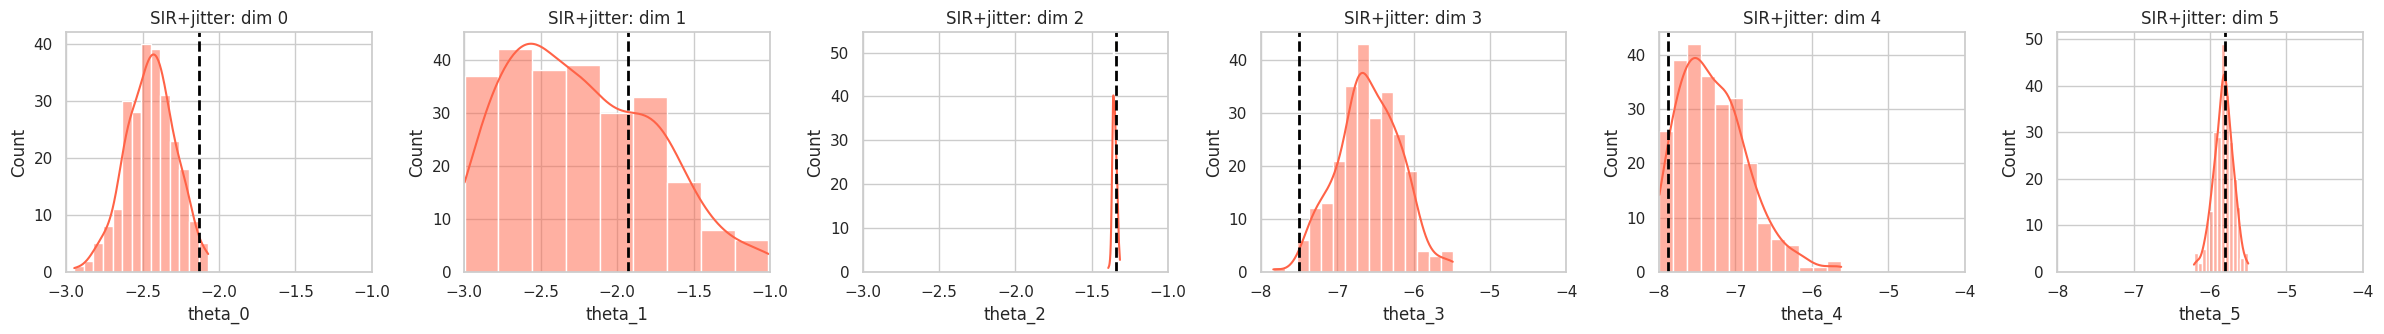

In [5]:
cp_sir = build_cp()

samples_sir = cp_sir.sample_via_sir_jitter(
    n_draws=100_000,
    n_final=N_SAMPLES
)

print("SIR+jitter sample shape:", tuple(samples_sir.shape))
summarize_samples(samples_sir, "SIR+jitter", theta_true)

## Legacy Adaptive Tempered SIR With Refinement

This section is kept for comparison with older runs. It is useful as a heuristic high-density particle generator, but it should not be treated as an exact posterior sampler.

The issue is the refinement step. The method draws a prior proposal pool, computes prior-importance weights, resamples promising particles, jitters them, and then keeps the highest untempered target-density points. Once the particles are jittered, their proposal distribution is no longer the prior. It is a data-adapted Gaussian mixture around the resampled particles. Because this legacy method does not evaluate that Gaussian-mixture proposal density and does not reweight the refined particles by `target / proposal`, the returned particles are not importance-corrected.

Interpretation:
- acceptable as an initializer, MAP-region finder, or visual diagnostic
- not acceptable as the final posterior sample used for calibrated uncertainty
- superseded by the corrected adaptive SIR section below


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 16.97it/s]
Adaptive SIR attempt 1/3: rescoring 500 refined samples: 100%|██████████| 10/10 [00:00<00:00, 36.26it/s]

Adaptive SIR attempt 1/3 drew 100000 proposals, refined 500, returned 250 samples. Temperature = 5.8140, ESS = 100.00.
Adaptive SIR sample shape: (250, 6)


,attempt,attempts_used,temperature,ess,raw_target_ess,target_ess,proposal_pool,refinement_pool,jitter_scale,reached_target
0,1,1,5.814015,100.000252,100.0,100.0,100000,500,0.15,True


,mean,std,min,max
theta_0,-2.409342,0.250691,-2.903705,-1.739060
theta_1,-2.258250,0.403940,-2.949622,-1.407935
theta_2,-1.348487,0.014789,-1.377028,-1.319460
theta_3,-6.665006,0.438283,-7.677893,-5.807546
theta_4,-6.954825,0.523034,-7.967144,-5.789265
theta_5,-5.860162,0.265123,-6.645732,-5.377833


/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

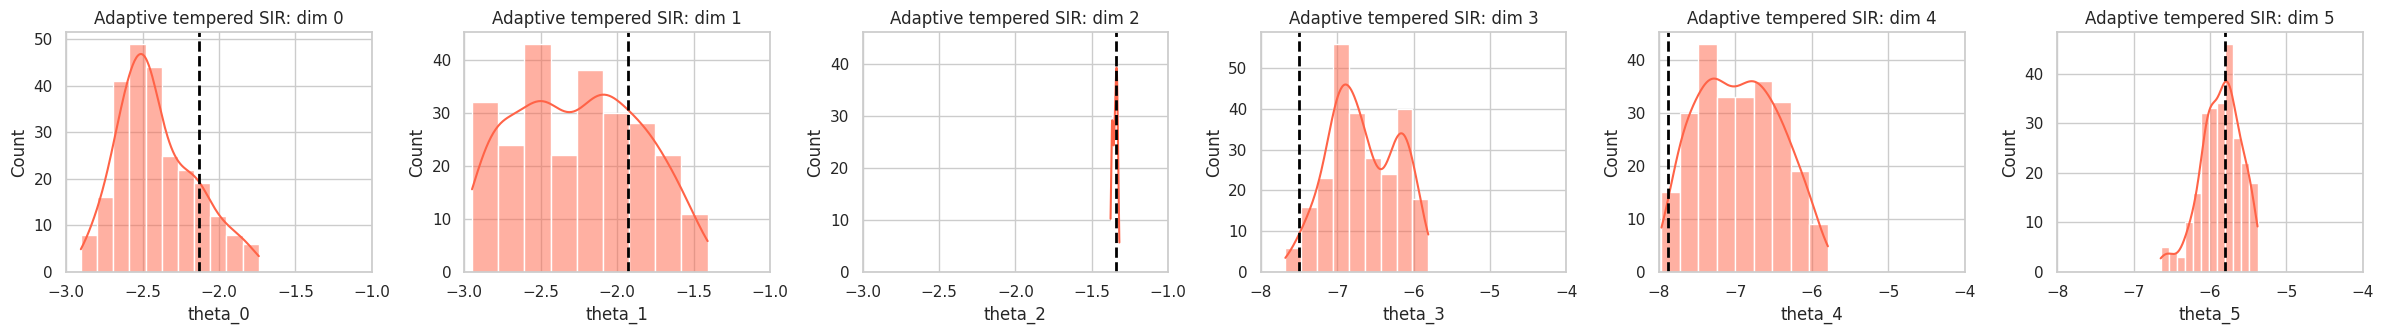

In [6]:
cp_adaptive = build_cp()

samples_adaptive = cp_adaptive.adaptive_sir(
    n_draws=100_000,
    n_final=N_SAMPLES,
    ess_min_frac=1e-3,
    oversample=2.0,
    jitter_scale=0.15,
)
adaptive_diag = cp_adaptive.last_adaptive_sir_diagnostics

print("Adaptive SIR sample shape:", tuple(samples_adaptive.shape))
if adaptive_diag is not None:
    display(pd.DataFrame([adaptive_diag]))
summarize_samples(samples_adaptive, "Adaptive tempered SIR", theta_true)


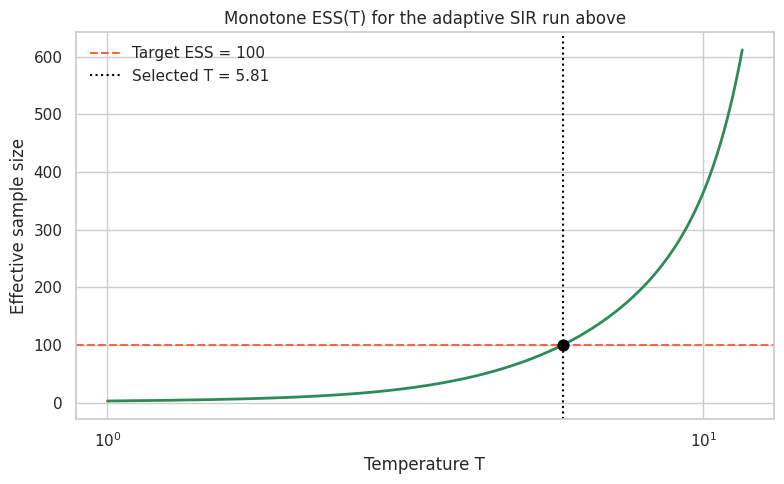

Selected temperature: 5.81401
Target ESS: 100.00
Achieved ESS at selected T: 100.00


In [7]:
log_weights = cp_adaptive.last_adaptive_sir_log_weights
if log_weights is None or adaptive_diag is None:
    raise RuntimeError('Run the adaptive SIR cell above first so the ESS(T) diagnostic can reuse that run.')

selected_temperature = float(adaptive_diag['temperature'])
target_ess = float(adaptive_diag['target_ess'])
selected_ess, _ = cp_adaptive._ess_and_weights(log_weights / selected_temperature)

t_max = max(selected_temperature * 2.0, 1.0)
if t_max == 1.0:
    temperatures = torch.tensor([1.0])
else:
    temperatures = torch.logspace(0.0, math.log10(t_max), steps=200)

ess_values = torch.tensor([cp_adaptive._ess_and_weights(log_weights / float(T))[0] for T in temperatures])

fig, ax = plt.subplots(1, 1, figsize=(8, 5), tight_layout=True)
ax.plot(temperatures.numpy(), ess_values.numpy(), color='seagreen', lw=2)
ax.axhline(target_ess, color='tomato', ls='--', lw=1.5, label=f'Target ESS = {target_ess:.0f}')
ax.axvline(selected_temperature, color='black', ls=':', lw=1.5, label=f'Selected T = {selected_temperature:.3g}')
ax.scatter([selected_temperature], [float(selected_ess)], color='black', s=60, zorder=5)
ax.set_xscale('log')
ax.set_xlabel('Temperature T')
ax.set_ylabel('Effective sample size')
ax.set_title('Monotone ESS(T) for the adaptive SIR run above')
ax.legend(frameon=False)
plt.show()

print(f'Selected temperature: {selected_temperature:.6g}')
print(f'Target ESS: {target_ess:.2f}')
print(f'Achieved ESS at selected T: {float(selected_ess):.2f}')


## Stability Over Repeated Runs

This section runs both `SIR+jitter` and `Adaptive SIR` 10 times with the same collective posterior. For each run, it computes the sample interquartile range (IQR) and the sample mean for each parameter dimension. We then compare two things: the variance of the IQR across runs, which measures stability, and the absolute error of the sample mean relative to the true parameter, which measures accuracy.


Evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 17.73it/s]


Sampled 250 points with jitter and reflection. ESS = 33.8590202331543


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 18.22it/s]
Adaptive SIR attempt 1/3: rescoring 500 refined samples: 100%|██████████| 10/10 [00:00<00:00, 35.33it/s]


Adaptive SIR attempt 1/3 drew 100000 proposals, refined 500, returned 250 samples. Temperature = 6.2650, ESS = 100.00.


Evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 16.62it/s]


...

Sampled 250 points with jitter and reflection. ESS = 17.969697952270508


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 19.20it/s]
Adaptive SIR attempt 1/3: rescoring 500 refined samples: 100%|██████████| 10/10 [00:00<00:00, 35.54it/s]

Adaptive SIR attempt 1/3 drew 100000 proposals, refined 500, returned 250 samples. Temperature = 6.3255, ESS = 100.00.


,sir_iqr_mean,sir_iqr_var,sir_mean_abs_error,adaptive_iqr_mean,adaptive_iqr_var,adaptive_mean_abs_error
theta_0,0.277165,0.005257,0.337407,0.390306,0.002084,0.285567
theta_1,0.724674,0.029198,0.272782,0.749455,0.002343,0.293793
theta_2,0.018535,0.000023,0.009292,0.022108,0.000006,0.005022
theta_3,0.565143,0.026412,0.882128,0.729397,0.002863,0.784838
theta_4,0.741061,0.023683,0.754088,0.734897,0.017728,0.779608
theta_5,0.272716,0.008288,0.052387,0.364145,0.001129,0.060250


,sir_mean_iqr_variance,sir_mean_abs_error,adaptive_mean_iqr_variance,adaptive_mean_abs_error
0,0.015477,0.384681,0.004359,0.36818


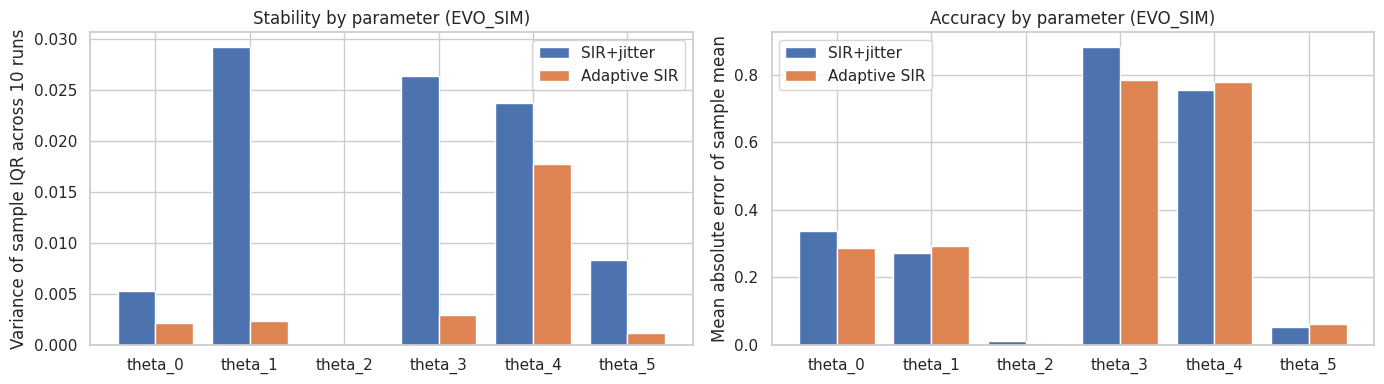

In [8]:
def sample_iqr(samples):
    samples = torch.as_tensor(samples)
    q75 = torch.quantile(samples, 0.75, dim=0)
    q25 = torch.quantile(samples, 0.25, dim=0)
    return q75 - q25


def run_sampler_stability(n_runs=10, sir_seed_offset=0, adaptive_seed_offset=10_000):
    sir_iqrs = []
    sir_means = []
    adaptive_iqrs = []
    adaptive_means = []

    for run_idx in range(n_runs):
        torch.manual_seed(1234 + sir_seed_offset + run_idx)
        cp_sir_repeat = build_cp()
        sir_samples_repeat = cp_sir_repeat.sample_via_sir_jitter(
            n_draws=100_000,
            n_final=N_SAMPLES,
        )
        sir_iqrs.append(sample_iqr(sir_samples_repeat))
        sir_means.append(torch.as_tensor(sir_samples_repeat).mean(0))

        torch.manual_seed(1234 + adaptive_seed_offset + run_idx)
        cp_adaptive_repeat = build_cp()
        adaptive_samples_repeat = cp_adaptive_repeat.adaptive_sir(
            n_draws=100_000,
            n_final=N_SAMPLES,
            ess_min_frac=1e-3,
            oversample=2.0,
            jitter_scale=0.5,
        )
        adaptive_iqrs.append(sample_iqr(adaptive_samples_repeat))
        adaptive_means.append(torch.as_tensor(adaptive_samples_repeat).mean(0))

    sir_iqrs = torch.stack(sir_iqrs)
    sir_means = torch.stack(sir_means)
    adaptive_iqrs = torch.stack(adaptive_iqrs)
    adaptive_means = torch.stack(adaptive_means)

    theta_target = theta_true.detach().cpu()
    sir_mean_abs_error = torch.abs(sir_means.detach().cpu() - theta_target)
    adaptive_mean_abs_error = torch.abs(adaptive_means.detach().cpu() - theta_target)

    return {
        "sir_iqrs": sir_iqrs,
        "sir_means": sir_means,
        "adaptive_iqrs": adaptive_iqrs,
        "adaptive_means": adaptive_means,
        "sir_iqr_var": torch.var(sir_iqrs, dim=0, unbiased=False),
        "adaptive_iqr_var": torch.var(adaptive_iqrs, dim=0, unbiased=False),
        "sir_mean_abs_error": sir_mean_abs_error,
        "adaptive_mean_abs_error": adaptive_mean_abs_error,
    }


stability = run_sampler_stability(n_runs=10)
dims = min(PLOT_DIMS, theta_true.shape[0])
theta_labels = [f"theta_{i}" for i in range(dims)]

stability_table = pd.DataFrame({
    "sir_iqr_mean": stability["sir_iqrs"].mean(0).detach().cpu().numpy()[:dims],
    "sir_iqr_var": stability["sir_iqr_var"].detach().cpu().numpy()[:dims],
    "sir_mean_abs_error": stability["sir_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims],
    "adaptive_iqr_mean": stability["adaptive_iqrs"].mean(0).detach().cpu().numpy()[:dims],
    "adaptive_iqr_var": stability["adaptive_iqr_var"].detach().cpu().numpy()[:dims],
    "adaptive_mean_abs_error": stability["adaptive_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims],
}, index=theta_labels)

overall_stability = pd.DataFrame([
    {
        "sir_mean_iqr_variance": float(stability["sir_iqr_var"].mean()),
        "sir_mean_abs_error": float(stability["sir_mean_abs_error"].mean()),
        "adaptive_mean_iqr_variance": float(stability["adaptive_iqr_var"].mean()),
        "adaptive_mean_abs_error": float(stability["adaptive_mean_abs_error"].mean()),
    }
])

display(stability_table)
display(overall_stability)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = list(range(dims))
axes[0].bar([i - 0.2 for i in x], stability["sir_iqr_var"].detach().cpu().numpy()[:dims], width=0.4, label="SIR+jitter")
axes[0].bar([i + 0.2 for i in x], stability["adaptive_iqr_var"].detach().cpu().numpy()[:dims], width=0.4, label="Adaptive SIR")
axes[0].set_xticks(x)
axes[0].set_xticklabels(theta_labels)
axes[0].set_ylabel("Variance of sample IQR across 10 runs")
axes[0].set_title(f"Stability by parameter ({SIM_NAME})")
axes[0].legend(loc="best")

axes[1].bar([i - 0.2 for i in x], stability["sir_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims], width=0.4, label="SIR+jitter")
axes[1].bar([i + 0.2 for i in x], stability["adaptive_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims], width=0.4, label="Adaptive SIR")
axes[1].set_xticks(x)
axes[1].set_xticklabels(theta_labels)
axes[1].set_ylabel("Mean absolute error of sample mean")
axes[1].set_title(f"Accuracy by parameter ({SIM_NAME})")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


## Comparison

The table below compares the empirical sample means from the collective-posterior sampling strategies. For GLU, the true parameter is especially easy to interpret because the posterior is directly tied to a noisy observation of the mean.

In [11]:
comparison = pd.DataFrame({
    "true_theta": theta_true.detach().cpu().numpy(),
    "rejection_mean": samples_rejection.mean(0).detach().cpu().numpy(),
    "mcmc_mean": samples_mcmc.mean(0).detach().cpu().numpy(),
    "sir_mean": samples_sir.mean(0).detach().cpu().numpy(),
    "legacy_adaptive_mean": samples_adaptive.mean(0).detach().cpu().numpy(),
})
comparison["rejection_abs_error"] = (comparison["rejection_mean"] - comparison["true_theta"]).abs()
comparison["mcmc_abs_error"] = (comparison["mcmc_mean"] - comparison["true_theta"]).abs()
comparison["sir_abs_error"] = (comparison["sir_mean"] - comparison["true_theta"]).abs()
comparison["legacy_adaptive_abs_error"] = (comparison["legacy_adaptive_mean"] - comparison["true_theta"]).abs()

display(comparison.head(PLOT_DIMS))


,true_theta,rejection_mean,mcmc_mean,sir_mean,legacy_adaptive_mean,rejection_abs_error,mcmc_abs_error,sir_abs_error,legacy_adaptive_abs_error
0,-2.131517,-2.432151,-2.382175,-2.447275,-2.409342,0.300634,0.250658,0.315758,0.277825
1,-1.929781,-2.218209,-2.005855,-2.242773,-2.258250,0.288428,0.076074,0.312992,0.328469
2,-1.339583,-1.347859,-1.346225,-1.350751,-1.348487,0.008277,0.006643,0.011169,0.008905
3,-7.504546,-6.651730,-6.688040,-6.588616,-6.665006,0.852816,0.816506,0.915929,0.839540
4,-7.882716,-7.050091,-6.936290,-7.288330,-6.954826,0.832624,0.946426,0.594386,0.927890
5,-5.802416,-5.837706,-6.074749,-5.826522,-5.860162,0.035290,0.272333,0.024107,0.057746


## Notes For Switching Simulators

To rerun this notebook on another benchmark:
1. Change `SIM_NAME` in the setup cell.
2. Re-run the notebook from the top.

The later cells use the same API for all supported simulators:
- prior from `get_prior(SIM_NAME)`
- replicate generation from the wrapper map
- pretrained posterior from the `DEFAULT_POSTERIORS` map
- collective posterior construction through `CollectivePosterior(...)`

If you want larger or more stable sample sets, the main knobs to increase are `N_EVAL`, `N_SAMPLES`, and `n_draws`.

For the adaptive sampler, the main tuning parameter is `ess_min_frac`:
- lower values make it faster and sharper, but can become less stable
- higher values make it more stable, but can oversmooth

The current default in this notebook is `n_draws=100_000`, `ess_min_frac=0.001`, `jitter_scale=0.15`, and `oversample=2.0`. With these settings, the adaptive sampler only increases the temperature if the raw importance weights have ESS below `100`.
